# PHASE 3 : Modelisation 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


## 1. Chargement des donnees et Split Train / Test

In [4]:
df = pd.read_csv('data/dataset.csv', low_memory=False)
df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f'Apres nettoyage : {df.shape[0]:,} lignes')

df['Label'] = df['Label'].str.strip()
df['Label'] = df['Label'].replace({
    'Web Attack \x96 Brute Force': 'Web Attack - Brute Force',
    'Web Attack \x96 XSS': 'Web Attack - XSS',
    'Web Attack \x96 Sql Injection': 'Web Attack - Sql Injection',
    'Web Attack \ufffd Brute Force': 'Web Attack - Brute Force',
    'Web Attack \ufffd XSS': 'Web Attack - XSS',
    'Web Attack \ufffd Sql Injection': 'Web Attack - Sql Injection',
})

df['label_binary'] = (df['Label'] != 'BENIGN').astype(int)

# Selection top 30 features par Random Forest
N_FEATURES = 30
X_all = df.drop(columns=['Label', 'label_binary'])
y_all = df['label_binary']
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_all, y_all)
top_features = pd.Series(rf.feature_importances_, index=X_all.columns).nlargest(N_FEATURES).index.tolist()

X = X_all[top_features]
y = y_all

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=top_features)
joblib.dump(scaler, 'pkls/standard_scaler_30.pkl')
joblib.dump(top_features, 'pkls/top30_features.pkl')

print(f'\nFeatures selectionnees : {N_FEATURES}')
print(f'Normal (0) : {(y == 0).sum():,}')
print(f'Anomalies (1) : {y.sum():,}')
print(f'Taux d\'anomalie : {y.mean():.2%}')


Apres nettoyage : 2,520,798 lignes

Features selectionnees : 30
Normal (0) : 2,095,057
Anomalies (1) : 425,741
Taux d'anomalie : 16.89%


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train : {X_train.shape[0]:,} lignes (anomalies : {y_train.mean():.2%})')
print(f'Test  : {X_test.shape[0]:,} lignes (anomalies : {y_test.mean():.2%})')

Train : 2,016,638 lignes (anomalies : 16.89%)
Test  : 504,160 lignes (anomalies : 16.89%)


## 2. Isolation Forest

In [8]:
contamination = y_train.mean()
print(f'Contamination estimee : {contamination:.4f}')

if_model = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_train.values)
print('Isolation Forest entraine.')

Contamination estimee : 0.1689
Isolation Forest entraine.


In [9]:
y_pred_if = (if_model.predict(X_test.values) == -1).astype(int)
y_score_if = -if_model.decision_function(X_test.values)

print('--- Isolation Forest ---')
print(f'Precision  : {precision_score(y_test, y_pred_if):.4f}')
print(f'Recall     : {recall_score(y_test, y_pred_if):.4f}')
print(f'F1-score   : {f1_score(y_test, y_pred_if):.4f}')
print(f'AUC-ROC    : {roc_auc_score(y_test, y_score_if):.4f}')

--- Isolation Forest ---
Precision  : 0.5846
Recall     : 0.5855
F1-score   : 0.5851
AUC-ROC    : 0.7852


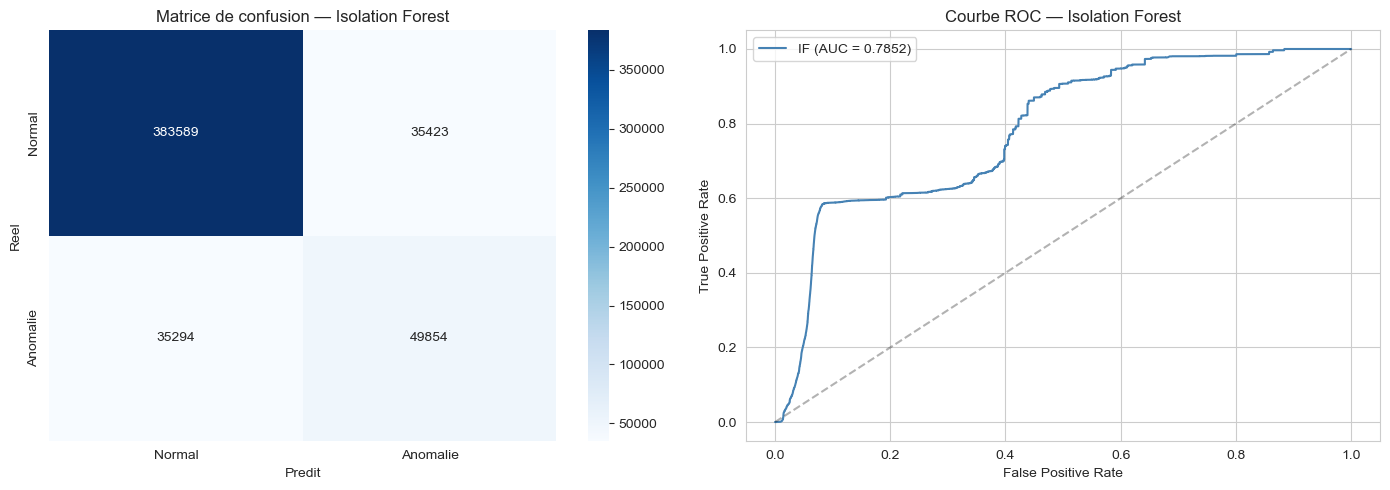

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_if = confusion_matrix(y_test, y_pred_if)
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
axes[0].set_title('Matrice de confusion — Isolation Forest')
axes[0].set_ylabel('Reel')
axes[0].set_xlabel('Predit')

fpr_if, tpr_if, _ = roc_curve(y_test, y_score_if)
axes[1].plot(fpr_if, tpr_if, label=f'IF (AUC = {roc_auc_score(y_test, y_score_if):.4f})', color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — Isolation Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. LSTM Autoencoder

In [12]:
SEQ_LEN = 20
BATCH_SIZE = 256
HIDDEN_DIM = 32
NUM_LAYERS = 1
EPOCHS = 100
LR = 1e-3
STRIDE = 10

In [13]:
def create_sequences(X_arr, y_arr, seq_len, stride):
    sequences = []
    labels = []
    for i in range(0, len(X_arr) - seq_len + 1, stride):
        sequences.append(X_arr[i:i+seq_len])
        labels.append(y_arr[i:i+seq_len].max())
    return np.array(sequences), np.array(labels)

X_train_seq, y_train_seq = create_sequences(X_train.values, y_train.values, SEQ_LEN, STRIDE)
X_test_seq, y_test_seq = create_sequences(X_test.values, y_test.values, SEQ_LEN, STRIDE)

X_train_benign = X_train_seq[y_train_seq == 0]

print(f'Train sequences : {X_train_seq.shape}')
print(f'Train BENIGN sequences : {X_train_benign.shape[0]:,}')
print(f'Test sequences  : {X_test_seq.shape}')
print(f'Train anomaly rate (sequence) : {y_train_seq.mean():.2%}')

Train sequences : (201662, 20, 30)
Train BENIGN sequences : 4,913
Test sequences  : (50415, 20, 30)
Train anomaly rate (sequence) : 97.56%


In [14]:
X_train_benign = X_train_seq[y_train_seq == 0]
print(f'Sequences BENIGN pour entrainement : {X_train_benign.shape[0]:,}')

Sequences BENIGN pour entrainement : 4,913


In [15]:
class SequenceDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.X[idx]

In [16]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, hidden_dim, num_layers=1):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.encoder = nn.LSTM(
            input_size=n_features, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True
        )
        self.decoder = nn.LSTM(
            input_size=n_features, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        batch_size = x.size(0)
        _, (hidden, cell) = self.encoder(x)
        decoder_input = torch.zeros(batch_size, self.seq_len, self.n_features, device=x.device)
        decoded, _ = self.decoder(decoder_input, (hidden, cell))
        output = self.output_layer(decoded)
        return output


model = LSTMAutoencoder(SEQ_LEN, X.shape[1], HIDDEN_DIM, NUM_LAYERS).to(device)
print(model)
print(f'\nParametres : {sum(p.numel() for p in model.parameters()):,}')

LSTMAutoencoder(
  (encoder): LSTM(30, 32, batch_first=True)
  (decoder): LSTM(30, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=30, bias=True)
)

Parametres : 17,374


In [17]:
train_dataset = SequenceDataset(X_train_benign)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f'Batches par epoch : {len(train_loader)}')

Batches par epoch : 20


In [18]:
train_losses = []
best_loss = float('inf')
patience = 10
patience_counter = 0

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'pkls/best_ae.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.6f}')

    if patience_counter >= patience:
        print(f'Early stopping a l\'epoch {epoch+1}')
        break

model.load_state_dict(torch.load('pkls/best_ae.pt', weights_only=True))
print(f'\nEntrainement termine. Best loss : {best_loss:.6f}')

Epoch   5/100 | Loss: 0.777072
Epoch  10/100 | Loss: 0.774636
Epoch  15/100 | Loss: 0.776278
Epoch  20/100 | Loss: 0.762762
Epoch  25/100 | Loss: 0.760243
Epoch  30/100 | Loss: 0.749212
Epoch  35/100 | Loss: 0.744471
Epoch  40/100 | Loss: 0.743552
Epoch  45/100 | Loss: 0.740546
Epoch  50/100 | Loss: 0.731025
Epoch  55/100 | Loss: 0.735194
Epoch  60/100 | Loss: 0.725437
Epoch  65/100 | Loss: 0.723807
Epoch  70/100 | Loss: 0.725466
Epoch  75/100 | Loss: 1.240183
Epoch  80/100 | Loss: 0.717692
Epoch  85/100 | Loss: 0.718919
Epoch  90/100 | Loss: 0.891233
Epoch  95/100 | Loss: 0.714553
Epoch 100/100 | Loss: 0.716509

Entrainement termine. Best loss : 0.713639


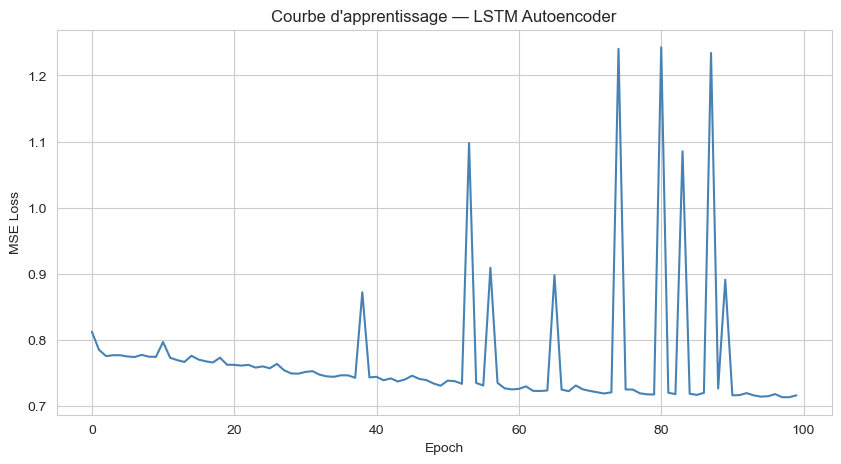

In [19]:
plt.plot(train_losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Courbe d\'apprentissage — LSTM Autoencoder')
plt.show()

Seuil d'anomalie (95e percentile) : 1.059966


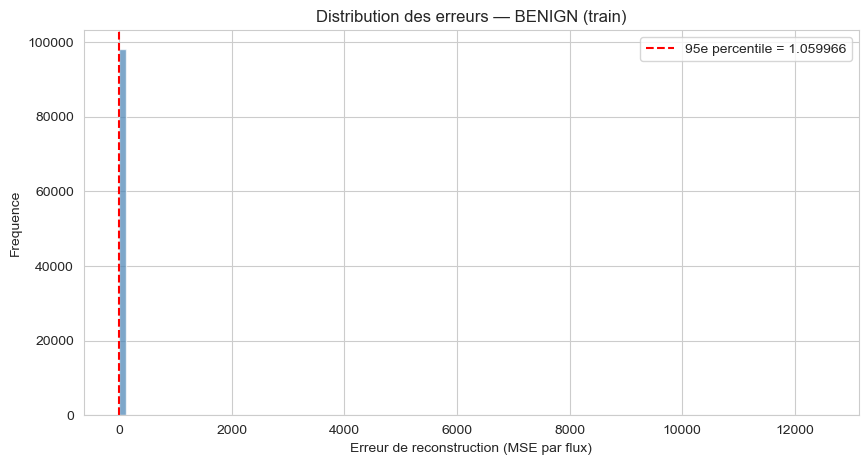

In [20]:
model.eval()
n_benign = min(len(X_train_benign), 20000)
train_benign_tensor = torch.tensor(X_train_benign[:n_benign], dtype=torch.float32).to(device)

with torch.no_grad():
    recon = model(train_benign_tensor)
    train_seq_errors = torch.mean((recon - train_benign_tensor) ** 2, dim=2).cpu().numpy()
train_errors = train_seq_errors.flatten()

threshold_95 = np.percentile(train_errors, 95)
print(f'Seuil d\'anomalie (95e percentile) : {threshold_95:.6f}')

plt.hist(train_errors, bins=100, color='steelblue', alpha=0.7)
plt.axvline(threshold_95, color='red', linestyle='--', label=f'95e percentile = {threshold_95:.6f}')
plt.xlabel('Erreur de reconstruction (MSE par flux)')
plt.ylabel('Frequence')
plt.title('Distribution des erreurs — BENIGN (train)')
plt.legend()
plt.show()

In [21]:
test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    recon_test = model(test_tensor)
    test_seq_errors = torch.mean((recon_test - test_tensor) ** 2, dim=2).cpu().numpy()

y_score_seq = test_seq_errors.flatten()
n_test_flows = len(y_test)
truncated = min(len(y_score_seq), n_test_flows)
y_test_truncated = y_test.values[:truncated]
y_score_flow = y_score_seq[:truncated]

print('--- Test de plusieurs seuils ---')
for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(train_errors, p)
    y_pred_flow = (y_score_flow > thr).astype(int)
    print(f'P={p:2d} | Precision={precision_score(y_test_truncated, y_pred_flow):.4f} | Recall={recall_score(y_test_truncated, y_pred_flow):.4f} | F1={f1_score(y_test_truncated, y_pred_flow):.4f}')

# Seuil par defaut 95e pour les sections suivantes
threshold = np.percentile(train_errors, 95)
y_pred_flow = (y_score_flow > threshold).astype(int)

print('\n--- LSTM Autoencoder (seuil 95e) ---')
print(f'Precision  : {precision_score(y_test_truncated, y_pred_flow):.4f}')
print(f'Recall     : {recall_score(y_test_truncated, y_pred_flow):.4f}')
print(f'F1-score   : {f1_score(y_test_truncated, y_pred_flow):.4f}')
print(f'AUC-ROC    : {roc_auc_score(y_test_truncated, y_score_flow):.4f}')

--- Test de plusieurs seuils ---
P=90 | Precision=0.1681 | Recall=0.1940 | F1=0.1801
P=92 | Precision=0.1680 | Recall=0.1754 | F1=0.1716
P=95 | Precision=0.1687 | Recall=0.1479 | F1=0.1576
P=97 | Precision=0.1693 | Recall=0.1203 | F1=0.1407
P=99 | Precision=0.1705 | Recall=0.0442 | F1=0.0702

--- LSTM Autoencoder (seuil 95e) ---
Precision  : 0.1687
Recall     : 0.1479
F1-score   : 0.1576
AUC-ROC    : 0.5000


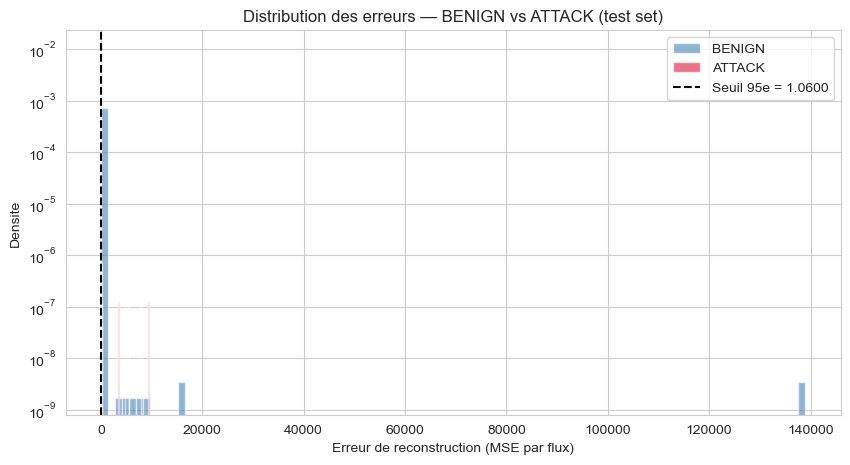

In [22]:
# Distribution des erreurs : BENIGN vs ATTACK sur le test set
benign_mask = y_test_truncated == 0
attack_mask = y_test_truncated == 1

plt.figure(figsize=(10, 5))
plt.hist(y_score_flow[benign_mask], bins=100, alpha=0.6, label='BENIGN', color='steelblue', density=True)
plt.hist(y_score_flow[attack_mask], bins=100, alpha=0.6, label='ATTACK', color='crimson', density=True)
plt.axvline(threshold, color='black', linestyle='--', label=f'Seuil 95e = {threshold:.4f}')
plt.xlabel('Erreur de reconstruction (MSE par flux)')
plt.ylabel('Densite')
plt.title('Distribution des erreurs — BENIGN vs ATTACK (test set)')
plt.legend()
plt.yscale('log')
plt.show()


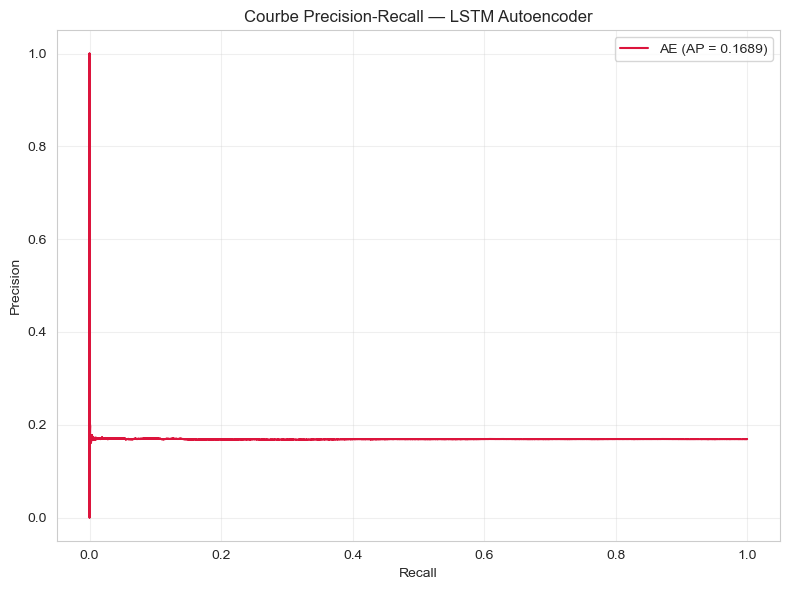

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test_truncated, y_score_flow)
ap = average_precision_score(y_test_truncated, y_score_flow)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', label=f'AE (AP = {ap:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — LSTM Autoencoder')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3b. Dense Autoencoder 

In [25]:
class DenseAutoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.n_features = n_features
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, n_features)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


dense_model = DenseAutoencoder(X.shape[1]).to(device)
print(dense_model)
print(f'\nParametres : {sum(p.numel() for p in dense_model.parameters()):,}')

DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=30, bias=True)
  )
)

Parametres : 1,286


In [ ]:
# Entrainement sur les flux BENIGN individuels
X_train_benign_dense = torch.tensor(X_train[y_train.values == 0].values, dtype=torch.float32).to(device)
dense_dataset = torch.utils.data.TensorDataset(X_train_benign_dense, X_train_benign_dense)
dense_loader = DataLoader(dense_dataset, batch_size=1024, shuffle=True)

dense_criterion = nn.MSELoss()
dense_optimizer = torch.optim.Adam(dense_model.parameters(), lr=1e-3)

dense_losses = []
dense_best_loss = float('inf')
dense_patience = 10
dense_patience_counter = 0

dense_model.train()
for epoch in range(50):
    epoch_loss = 0
    for batch_x, batch_y in dense_loader:
        dense_optimizer.zero_grad()
        recon = dense_model(batch_x)
        loss = dense_criterion(recon, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dense_model.parameters(), max_norm=1.0)
        dense_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dense_loader)
    dense_losses.append(avg_loss)

    if avg_loss < dense_best_loss:
        dense_best_loss = avg_loss
        dense_patience_counter = 0
        torch.save(dense_model.state_dict(), 'pkls/dense_ae.pt')
    else:
        dense_patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/50 | Loss: {avg_loss:.6f}')

    if dense_patience_counter >= dense_patience:
        print(f'Early stopping a l\'epoch {epoch+1}')
        break

dense_model.load_state_dict(torch.load('pkls/dense_ae.pt', weights_only=True))
print(f'\nEntrainement termine. Best loss : {dense_best_loss:.6f}')

Epoch   5/50 | Loss: 0.059064
Epoch  10/50 | Loss: 0.021417
Epoch  15/50 | Loss: 0.013927
Epoch  20/50 | Loss: 0.013437


In [ ]:
# Evaluation
dense_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
    recon_dense = dense_model(X_test_tensor)
    dense_errors = torch.mean((recon_dense - X_test_tensor) ** 2, dim=1).cpu().numpy()

precision, recall, thresholds = precision_recall_curve(y_test, dense_errors)
# Seuil sur train BENIGN
with torch.no_grad():
    recon_train = dense_model(X_train_benign_dense)
    dense_train_errors = torch.mean((recon_train - X_train_benign_dense) ** 2, dim=1).cpu().numpy()

print('--- Dense Autoencoder : test de plusieurs seuils ---')
for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(dense_train_errors, p)
    y_pred_dense = (dense_errors > thr).astype(int)
    print(f'P={p:2d} | Precision={precision_score(y_test, y_pred_dense):.4f} | Recall={recall_score(y_test, y_pred_dense):.4f} | F1={f1_score(y_test, y_pred_dense):.4f}')

thr_95 = np.percentile(dense_train_errors, 95)
print('--- Dense Autoencoder : recherche de seuils pour haut recall ---')
for target_recall in [0.95, 0.99, 0.999, 1.0]:
    mask = recall[:-1] >= target_recall
    if mask.any():
        best_idx = np.argmax(precision[:-1][mask])
        best_thr = thresholds[best_idx]
        best_p = precision[:-1][mask][best_idx]
        best_r = recall[:-1][mask][best_idx]
        y_pred_dense = (dense_errors > best_thr).astype(int)
        f1 = f1_score(y_test, y_pred_dense)
        print(f'Recall >= {target_recall:.3f} | Precision={best_p:.4f} | Recall={best_r:.4f} | F1={f1:.4f} | Seuil={best_thr:.4f}')
    else:
        print(f'Recall >= {target_recall:.3f} impossible')

# Choix : recall >= 0.99 avec meilleure precision
target_recall = 0.99
mask = recall[:-1] >= target_recall
best_idx = np.argmax(precision[:-1][mask])
thr_best = thresholds[best_idx]
y_pred_dense = (dense_errors > thr_best).astype(int)
print(f'\n--- Dense Autoencoder (seuil optimise recall 99%) ---')
print(f'Precision  : {precision_score(y_test, y_pred_dense):.4f}')
print(f'Recall     : {recall_score(y_test, y_pred_dense):.4f}')
print(f'F1-score   : {f1_score(y_test, y_pred_dense):.4f}')
print(f'AUC-ROC    : {roc_auc_score(y_test, dense_errors):.4f}')


In [ ]:
# Comparaison finale IF vs LSTM AE vs Dense AE
y_pred_if = (if_model.predict(X_test.values) == -1).astype(int)
y_score_if = -if_model.decision_function(X_test.values)

comparison = pd.DataFrame({
    'Modele': ['Isolation Forest', 'LSTM Autoencoder', 'Dense Autoencoder'],
    'Precision': [
        precision_score(y_test, y_pred_if),
        precision_score(y_test_truncated, y_pred_flow),
        precision_score(y_test, y_pred_dense)
    ],
    'Recall': [
        recall_score(y_test, y_pred_if),
        recall_score(y_test_truncated, y_pred_flow),
        recall_score(y_test, y_pred_dense)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_if),
        f1_score(y_test_truncated, y_pred_flow),
        f1_score(y_test, y_pred_dense)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_score_if),
        roc_auc_score(y_test_truncated, y_score_flow),
        roc_auc_score(y_test, dense_errors)
    ]
})

comparison.set_index('Modele', inplace=True)
comparison.round(4)

## 4. MLP Supervise


In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            
        )
    def forward(self, x):
        return self.net(x)

mlp_model = MLPClassifier(X.shape[1]).to(device)
print(mlp_model)

In [31]:
from sklearn.utils.class_weight import compute_class_weight

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1).to(device)

train_dataset_mlp = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=2048, shuffle=True)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]], dtype=torch.float32).to(device)

criterion_mlp = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
scheduler_mlp = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, mode='min', factor=0.5, patience=5)

best_val_loss = float('inf')
patience = 10
counter = 0

mlp_model.train()
for epoch in range(50):
    epoch_loss = 0
    for batch_x, batch_y in train_loader_mlp:
        optimizer_mlp.zero_grad()
        outputs = mlp_model(batch_x)
        loss = criterion_mlp(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
        optimizer_mlp.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_mlp)
    scheduler_mlp.step(avg_loss)

    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        counter = 0
        torch.save(mlp_model.state_dict(), 'pkls/mlp_classifier.pt')
    else:
        counter += 1

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/50 | Loss: {avg_loss:.6f}')

    if counter >= patience:
        print(f'Early stopping a l\'epoch {epoch+1}')
        break

mlp_model.load_state_dict(torch.load('pkls/mlp_classifier.pt', weights_only=True))
print(f'\nEntrainement termine. Best loss : {best_val_loss:.6f}')

Epoch  15/50 | Loss: 0.088387
Epoch  20/50 | Loss: 0.081418
Epoch  25/50 | Loss: 0.076966
Epoch  30/50 | Loss: 0.076149
Epoch  35/50 | Loss: 0.074081
Epoch  40/50 | Loss: 0.072951
Epoch  45/50 | Loss: 0.063835
Epoch  50/50 | Loss: 0.061618

Entrainement termine. Best loss : 0.061557


In [32]:
from sklearn.metrics import precision_recall_curve

mlp_model.eval()
with torch.no_grad():
    mlp_proba = torch.sigmoid(mlp_model(X_test_tensor)).cpu().numpy().flatten()

mlp_pred = (mlp_proba > 0.5).astype(int)

print('--- MLP Supervise (seuil 0.5) ---')
print(f'Precision  : {precision_score(y_test, mlp_pred):.4f}')
print(f'Recall     : {recall_score(y_test, mlp_pred):.4f}')
print(f'F1-score   : {f1_score(y_test, mlp_pred):.4f}')
print(f'AUC-ROC    : {roc_auc_score(y_test, mlp_proba):.4f}')

# Best threshold
precision_mlp, recall_mlp, thr_mlp = precision_recall_curve(y_test, mlp_proba)
f1_mlp = 2 * (precision_mlp * recall_mlp) / (precision_mlp + recall_mlp + 1e-10)
best_idx = np.argmax(f1_mlp)
best_thr = thr_mlp[best_idx]
mlp_pred_best = (mlp_proba > best_thr).astype(int)

print(f'\n--- MLP Supervise (seuil F1-optimal={best_thr:.4f}) ---')
print(f'Precision  : {precision_score(y_test, mlp_pred_best):.4f}')
print(f'Recall     : {recall_score(y_test, mlp_pred_best):.4f}')
print(f'F1-score   : {f1_score(y_test, mlp_pred_best):.4f}')

print('\n--- Precision a haut recall ---')
for target_r in [0.95, 0.99, 0.999]:
    mask = recall_mlp[:-1] >= target_r
    if mask.any():
        p_at_r = max(precision_mlp[:-1][mask])
        print(f'P@R{target_r:.3f} = {p_at_r:.4f}')


--- MLP Supervise (seuil 0.5) ---
Precision  : 0.9749
Recall     : 0.9880
F1-score   : 0.9814
AUC-ROC    : 0.9996

--- MLP Supervise (seuil F1-optimal=0.7823) ---
Precision  : 0.9913
Recall     : 0.9811
F1-score   : 0.9862

--- Precision a haut recall ---
P@R0.950 = 0.9965
P@R0.990 = 0.9680
P@R0.999 = 0.7366


In [33]:
# Final comparison: add supervised models
from sklearn.ensemble import RandomForestClassifier

print('Training Random Forest on current features...')
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
rf_proba_final = rf_final.predict_proba(X_test)[:, 1]
rf_pred_final = rf_final.predict(X_test)

comparison_final = pd.DataFrame({
    'Modele': ['Isolation Forest', 'LSTM Autoencoder', 'Dense Autoencoder', 'MLP Supervise', 'Random Forest'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_score_if),
        roc_auc_score(y_test_truncated, y_score_flow),
        roc_auc_score(y_test, dense_errors),
        roc_auc_score(y_test, mlp_proba),
        roc_auc_score(y_test, rf_proba_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_if),
        precision_score(y_test_truncated, y_pred_flow),
        precision_score(y_test, y_pred_dense),
        precision_score(y_test, mlp_pred),
        precision_score(y_test, rf_pred_final)
    ],
    'Recall': [
        recall_score(y_test, y_pred_if),
        recall_score(y_test_truncated, y_pred_flow),
        recall_score(y_test, y_pred_dense),
        recall_score(y_test, mlp_pred),
        recall_score(y_test, rf_pred_final)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_if),
        f1_score(y_test_truncated, y_pred_flow),
        f1_score(y_test, y_pred_dense),
        f1_score(y_test, mlp_pred),
        f1_score(y_test, rf_pred_final)
    ]
})

comparison_final.set_index('Modele', inplace=True)
comparison_final.round(4)

Training Random Forest on current features...


,AUC-ROC,Precision,Recall,F1-score
Modele,,,,
Isolation Forest,0.7852,0.5846,0.5855,0.5851
LSTM Autoencoder,0.5000,0.1687,0.1479,0.1576
Dense Autoencoder,0.8888,0.3040,0.9900,0.4651
MLP Supervise,0.9996,0.9749,0.9880,0.9814
Random Forest,0.9998,0.9967,0.9958,0.9963


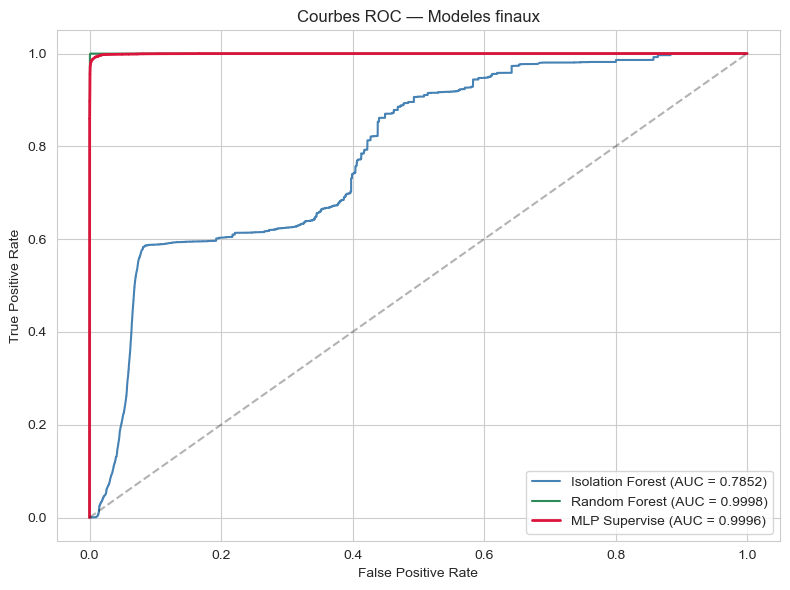

In [34]:
# Courbes ROC : MLP vs Random Forest vs Isolation Forest
fpr_if, tpr_if, _ = roc_curve(y_test, y_score_if)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba_final)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_score(y_test, y_score_if):.4f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba_final):.4f})', color='seagreen')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP Supervise (AUC = {roc_auc_score(y_test, mlp_proba):.4f})', color='crimson', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC — Modeles finaux')
plt.legend()
plt.tight_layout()
plt.show()


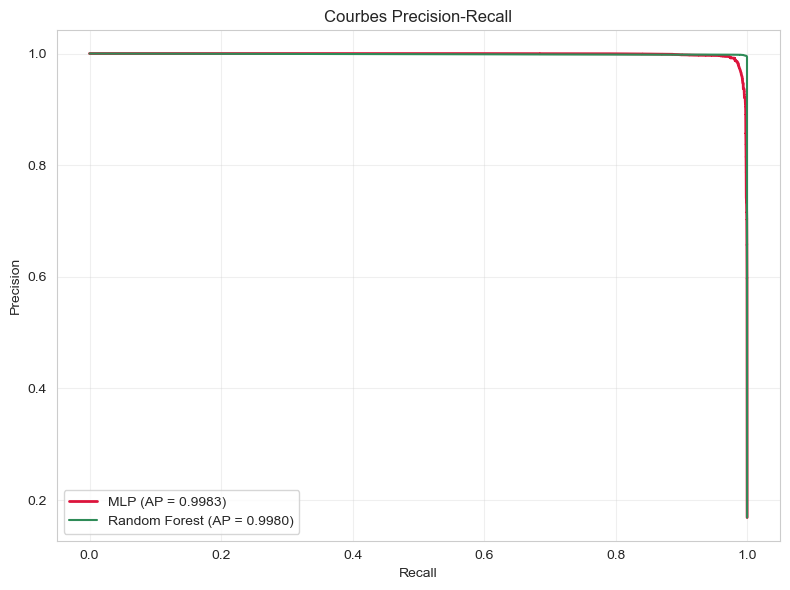

In [35]:
# Courbe Precision-Recall : MLP Supervise
precision_mlp, recall_mlp, thr_mlp = precision_recall_curve(y_test, mlp_proba)
ap_mlp = average_precision_score(y_test, mlp_proba)
precision_rf, recall_rf, thr_rf = precision_recall_curve(y_test, rf_proba_final)
ap_rf = average_precision_score(y_test, rf_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall_mlp, precision_mlp, label=f'MLP (AP = {ap_mlp:.4f})', color='crimson', linewidth=2)
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.4f})', color='seagreen')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


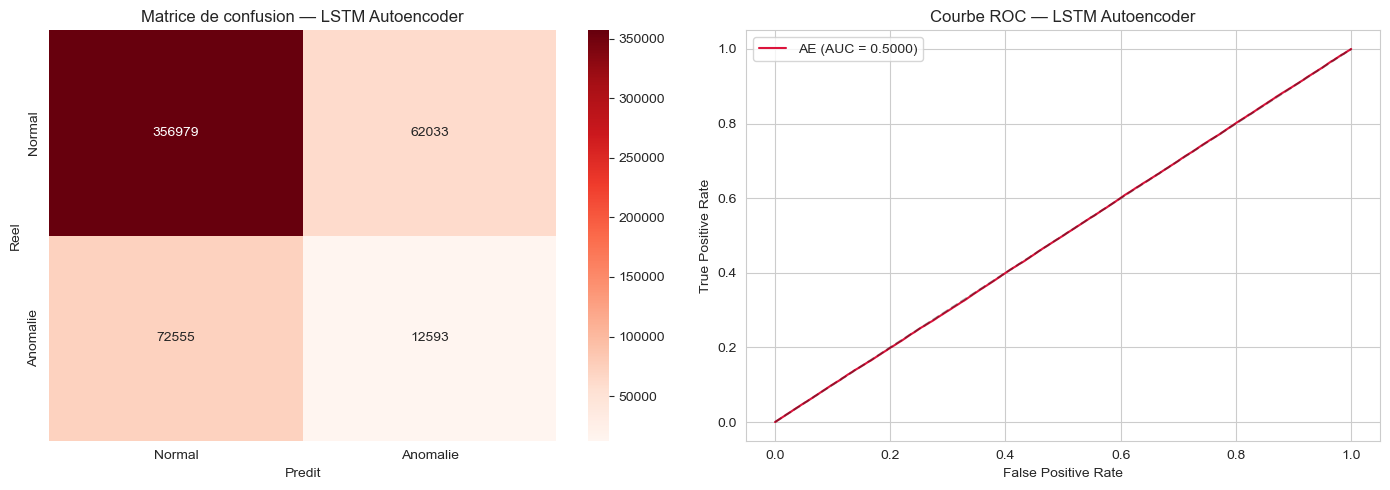

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ae = confusion_matrix(y_test_truncated, y_pred_flow)
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
axes[0].set_title('Matrice de confusion — LSTM Autoencoder')
axes[0].set_ylabel('Reel')
axes[0].set_xlabel('Predit')

fpr_ae, tpr_ae, _ = roc_curve(y_test_truncated, y_score_flow)
axes[1].plot(fpr_ae, tpr_ae, label=f'AE (AUC = {roc_auc_score(y_test_truncated, y_score_flow):.4f})', color='crimson')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC — LSTM Autoencoder')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sauvegarde des modeles


In [38]:
# Sauvegarder tous les modeles
import os
os.makedirs('pkls', exist_ok=True)

# MLP (meilleur modele)
torch.save(mlp_model.state_dict(), 'pkls/mlp_model.pt')

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
joblib.dump(rf_final, 'pkls/rf_model.pkl')

# Isolation Forest
joblib.dump(if_model, 'pkls/if_model.pkl')

# Dense Autoencoder
torch.save(dense_model.state_dict(), 'pkls/dense_ae.pt')

# Scaler et features
joblib.dump(scaler, 'pkls/scaler.pkl')
joblib.dump(top_features, 'pkls/features.pkl')

# Config MLP
mlp_config = {
    'n_features': X.shape[1],
    'features': top_features,
    'scaler': 'standard'
}
joblib.dump(mlp_config, 'pkls/mlp_config.pkl')

print('Modeles sauvegardes :')
print('  pkls/mlp_model.pt      (MLP supervise - meilleur)')
print('  pkls/rf_model.pkl      (Random Forest)')
print('  pkls/if_model.pkl      (Isolation Forest)')
print('  pkls/dense_ae.pt       (Dense Autoencoder)')
print('  pkls/scaler.pkl        (StandardScaler)')
print('  pkls/features.pkl      (Top 30 features)')
print('  pkls/mlp_config.pkl    (Config MLP)')


Modeles sauvegardes :
  pkls/mlp_model.pt      (MLP supervise - meilleur)
  pkls/rf_model.pkl      (Random Forest)
  pkls/if_model.pkl      (Isolation Forest)
  pkls/dense_ae.pt       (Dense Autoencoder)
  pkls/scaler.pkl        (StandardScaler)
  pkls/features.pkl      (Top 30 features)
  pkls/mlp_config.pkl    (Config MLP)
